# ⚽ Fotbollsprojekt – VM Slutspel 2026

**Mål:** Analysera VM-matcher och deras resultat.

**Metod:** Skapa matcher, spara i JSON, analysera med klasser och funktioner.

**Verktyg:** Python, JSON, matplotlib

## Importera bibliotek

In [1]:
import json
import os
import random
from datetime import datetime
import matplotlib.pyplot as plt

print("✅ Alla bibliotek importerade!")

✅ Alla bibliotek importerade!


## Klasser: VMMatch och SlutspelsMatch

- **VMMatch** – en mall för en VM-match (lag1, lag2, mål, omgång)
- **SlutspelsMatch** – ärver från VMMatch och lägger till förlängning

In [2]:
class VMMatch:
    """En klass som representerar en VM-match."""
    
    def __init__(self, lag1, lag2, lag1_mal, lag2_mal, omgång):
        self.lag1 = lag1
        self.lag2 = lag2
        self.lag1_mal = lag1_mal
        self.lag2_mal = lag2_mal
        self.omgång = omgång
    
    def resultat(self):
        return f"{self.lag1} {self.lag1_mal} - {self.lag2_mal} {self.lag2}"
    
    def vinnare(self):
        if self.lag1_mal > self.lag2_mal:
            return self.lag1
        elif self.lag2_mal > self.lag1_mal:
            return self.lag2
        else:
            return "Oavgjord"
    
    def till_dict(self):
        return {
            "lag1": self.lag1,
            "lag2": self.lag2,
            "lag1_mal": self.lag1_mal,
            "lag2_mal": self.lag2_mal,
            "omgång": self.omgång
        }
    
    def __str__(self):
        return f"[{self.omgång}] {self.resultat()}"


class SlutspelsMatch(VMMatch):
    """En barnklass som ärver från VMMatch och lägger till förlängning."""
    
    def __init__(self, lag1, lag2, lag1_mal, lag2_mal, omgång, förlängning=False):
        super().__init__(lag1, lag2, lag1_mal, lag2_mal, omgång)
        self.förlängning = förlängning
    
    def till_dict(self):
        data = super().till_dict()
        data["förlängning"] = self.förlängning
        return data
    
    def __str__(self):
        text = super().__str__()
        if self.förlängning:
            text += " (efter förlängning)"
        return text

print("✅ Klasserna VMMatch och SlutspelsMatch är skapade!")

✅ Klasserna VMMatch och SlutspelsMatch är skapade!


### Test av klasserna

In [3]:
test_match = VMMatch("Spanien", "Argentina", 1, 0, "Final")
print(test_match)
print()

test_slutspel = SlutspelsMatch("England", "Norge", 2, 1, "Kvartsfinal", förlängning=True)
print(test_slutspel)

[Final] Spanien 1 - 0 Argentina

[Kvartsfinal] England 2 - 1 Norge (efter förlängning)


## Funktionen skapa_matcher()

Skapar alla 8 VM-matcher från slutspelet 2026 och returnerar dem som en lista.

In [4]:
def skapa_matcher():
    """Skapar alla 8 VM-matcher från slutspelet 2026."""
    matcher = [
        SlutspelsMatch("Frankrike", "Marocko", 2, 0, "Kvartsfinal", förlängning=False),
        SlutspelsMatch("Spanien", "Belgien", 2, 1, "Kvartsfinal", förlängning=False),
        SlutspelsMatch("England", "Norge", 2, 1, "Kvartsfinal", förlängning=True),
        SlutspelsMatch("Argentina", "Schweiz", 3, 1, "Kvartsfinal", förlängning=True),
        SlutspelsMatch("Spanien", "Frankrike", 2, 0, "Semifinal", förlängning=False),
        SlutspelsMatch("Argentina", "England", 2, 1, "Semifinal", förlängning=False),
        SlutspelsMatch("England", "Frankrike", 6, 4, "Bronsmatch", förlängning=False),
        SlutspelsMatch("Spanien", "Argentina", 1, 0, "Final", förlängning=True)
    ]
    return matcher

print("✅ Funktionen skapa_matcher() är skapad!")

✅ Funktionen skapa_matcher() är skapad!


### Test av skapa_matcher()

In [5]:
alla_matcher = skapa_matcher()
print("Antal matcher:", len(alla_matcher))
print()

for match in alla_matcher:
    print(match)

Antal matcher: 8

[Kvartsfinal] Frankrike 2 - 0 Marocko
[Kvartsfinal] Spanien 2 - 1 Belgien
[Kvartsfinal] England 2 - 1 Norge (efter förlängning)
[Kvartsfinal] Argentina 3 - 1 Schweiz (efter förlängning)
[Semifinal] Spanien 2 - 0 Frankrike
[Semifinal] Argentina 2 - 1 England
[Bronsmatch] England 6 - 4 Frankrike
[Final] Spanien 1 - 0 Argentina (efter förlängning)


## Funktionen spara_till_json()

Sparar en lista med matcher till en JSON-fil så att vi kan läsa dem senare.

In [ ]:
def spara_till_json(matcher, filnamn="vm_matcher.json"):
    """Sparar en lista med matcher till en JSON-fil."""
    try:
        data = [match.till_dict() for match in matcher]
        
        with open(filnamn, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        
        print(f"✅ {len(matcher)} matcher sparade till {filnamn}")
        return True
    
    except Exception as e:
        print(f"❌ Fel vid sparande: {e}")
        return False

print("✅ Funktionen spara_till_json() är skapad!")

✅ Funktionen spara_till_json() är skapad!


### Test av spara_till_json()

In [7]:
resultat = spara_till_json(alla_matcher)
print("Lyckades?", resultat)

✅ 8 matcher sparade till vm_matcher.json
Lyckades? True


## Funktionen ladda_från_json()

Läser in matcher från en JSON-fil och gör om dem till objekt.

In [8]:
def ladda_från_json(filnamn="vm_matcher.json"):
    """Laddar matcher från en JSON-fil."""
    try:
        if not os.path.exists(filnamn):
            print(f"⚠️ Filen {filnamn} finns inte.")
            return []
        
        with open(filnamn, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        matcher = []
        for rad in data:
            match = VMMatch(
                rad["lag1"],
                rad["lag2"],
                rad["lag1_mal"],
                rad["lag2_mal"],
                rad["omgång"]
            )
            matcher.append(match)
        
        print(f"✅ {len(matcher)} matcher laddade från {filnamn}")
        return matcher
    
    except Exception as e:
        print(f"❌ Fel vid laddning: {e}")
        return []

print("✅ Funktionen ladda_från_json() är skapad!")

✅ Funktionen ladda_från_json() är skapad!


### Test av ladda_från_json()

In [9]:
laddade_matcher = ladda_från_json()
print("Antal laddade matcher:", len(laddade_matcher))
print()

for match in laddade_matcher:
    print(match)

✅ 8 matcher laddade från vm_matcher.json
Antal laddade matcher: 8

[Kvartsfinal] Frankrike 2 - 0 Marocko
[Kvartsfinal] Spanien 2 - 1 Belgien
[Kvartsfinal] England 2 - 1 Norge
[Kvartsfinal] Argentina 3 - 1 Schweiz
[Semifinal] Spanien 2 - 0 Frankrike
[Semifinal] Argentina 2 - 1 England
[Bronsmatch] England 6 - 4 Frankrike
[Final] Spanien 1 - 0 Argentina


## Funktionen beräkna_statistik()

Räknar ut statistik från matcherna: antal matcher, totala mål, medelvärde, max/min.

In [10]:
def beräkna_statistik(matcher):
    """Beräknar statistik från en lista med matcher."""
    if not matcher:
        return {}
    
    total_mål = 0
    antal_oavgjorda = 0
    mål_per_match = []
    
    for match in matcher:
        mål = match.lag1_mal + match.lag2_mal
        total_mål += mål
        mål_per_match.append(mål)
        
        if match.vinnare() == "Oavgjord":
            antal_oavgjorda += 1
    
    statistik = {
        "antal_matcher": len(matcher),
        "total_mål": total_mål,
        "medel_mål_per_match": round(total_mål / len(matcher), 2),
        "max_mål": max(mål_per_match),
        "min_mål": min(mål_per_match),
        "antal_oavgjorda": antal_oavgjorda
    }
    
    return statistik

print("✅ Funktionen beräkna_statistik() är skapad!")

✅ Funktionen beräkna_statistik() är skapad!


### Test av beräkna_statistik()

In [11]:
statistik = beräkna_statistik(alla_matcher)

print("=== STATISTIK ===")
for nyckel, värde in statistik.items():
    print(f"{nyckel}: {värde}")

=== STATISTIK ===
antal_matcher: 8
total_mål: 28
medel_mål_per_match: 3.5
max_mål: 10
min_mål: 1
antal_oavgjorda: 0


## Visualisering

Ritar ett stapeldiagram över antal mål per match.

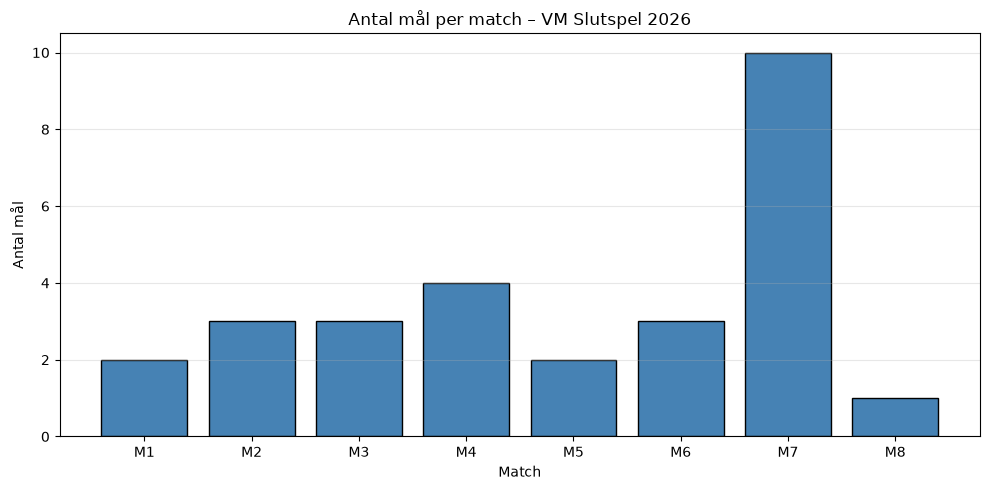

✅ Diagrammet är klart!


In [12]:
# Förbered data för diagrammet
matcher_namn = []
antal_mål = []

for i, match in enumerate(alla_matcher, 1):
    matcher_namn.append(f"M{i}")
    antal_mål.append(match.lag1_mal + match.lag2_mal)

# Skapa diagrammet
plt.figure(figsize=(10, 5))
plt.bar(matcher_namn, antal_mål, color="steelblue", edgecolor="black")

plt.title("Antal mål per match – VM Slutspel 2026")
plt.xlabel("Match")
plt.ylabel("Antal mål")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Diagrammet är klart!")